# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [38]:
# Part 1: your work here
import numpy as np
import pandas as pd
import astropy 

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
data = np.genfromtxt('../../labs/01/data/zahisr2.csv', delimiter=',', names = True)

In [40]:
x, y, sigma_y = data['x'], data['y'], data['sigma_y']

In [41]:
# scipy.optimize curve fit for fitting linear model (as opposed to statsmodels and other methods and libraries)
# absolute_sigma = True

def line(x, m, b):
    return m * x + b
 
popt, pcov = curve_fit(line, x, y, sigma=sigma_y, absolute_sigma=True) #popt is the estimated parameters and pcov has the variances along the diagonal with parameter covariances in the other entries
m, b = popt
sigma_m, sigma_b = np.sqrt(np.diag(pcov))
initial_fit = m*x + b

R2 = r2_score(y, initial_fit)
RMSE = root_mean_squared_error(y, initial_fit)

print(f"m = {m:.4f} +- {sigma_m:.4f}")
print(f"b = {b:.4f} +- {sigma_b:.4f}")
print(f"R2 = {R2:.4f}")
print(f"RMSE = {RMSE:.4f}")

m = 2.5075 +- 0.1140
b = 17.9199 +- 0.6009
R2 = 0.6288
RMSE = 6.6468


In [42]:
# absolute_sigma = False

popt, pcov = curve_fit(line, x, y, sigma=sigma_y, absolute_sigma=False)
m2, b2 = popt
sigma_m2, sigma_b2 = np.sqrt(np.diag(pcov))

print("Model's m and b uncertainties rescaled by the Chi-Squared of the fit (sigma_y isn't treated as correct)")
print(f"m2 = {m2:.4f} +- {sigma_m2:.4f}")
print(f"b2 = {b2:.4f} +- {sigma_b2:.4f}")

Model's m and b uncertainties rescaled by the Chi-Squared of the fit (sigma_y isn't treated as correct)
m2 = 2.5075 +- 0.3621
b2 = 17.9199 +- 1.9082


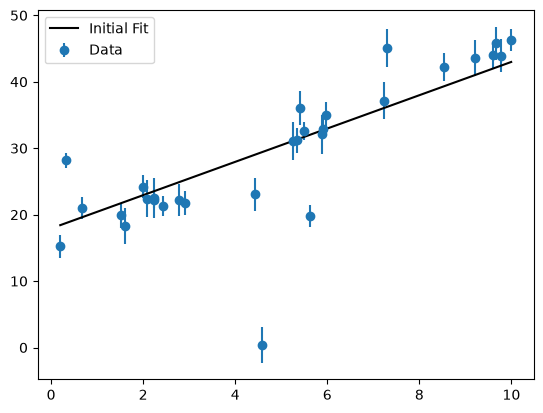

In [43]:
# plot
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.legend();

In [44]:
# Finding Chi-Squared
chi_sq = np.sum( (( y - initial_fit) / sigma_y)**2 )
reduced_chi_sq = chi_sq / (len(y) - 2) # the two fitted parameters are B0 and B1 (m and b)
print(f"The Reduced Chi-Squared for the initial linear model is: {reduced_chi_sq:.4f}")

The Reduced Chi-Squared for the initial linear model is: 10.0830


**ANSWER (a few sentences):**

The initial linear model has the following coefficients:
- m = **2.5075** +- **0.1140**
- b = **17.9199** +- **0.6009**

It was created using scipy.optimize's curve_fit function with the **absolute_sigma argument set to True**; this means that the data's "sigma_y" column was treated as the absolute true value for the uncertainty in y. As demonstrated above, if this was set to false, the uncertainties in the model parameters raised significantly in order to normalize to the residual variance. I believe setting this to false would lead to a similar effect to the AI output since the model is increasing its error bars to make sure the the fit of the model looks better. In the implementation I went forward with (absolute_sigma set to True), I believe the uncertainty in m and b are more accurate as they were not subject to any rescaling and were created from sigma_y.

The initial linear model has a reduced chi squared of **10.083**, signifying a poor fit to the data. When plotting, we can maybe attribute this to outliers in the data set that linear models are susceptible to.

## Part 2: A fit you can defend (40%)

### Sigma Clipping Model

In [48]:
# Part 2: your work here
# Sigma Clipping
k = 3

mask = np.ones_like(x, dtype = bool)
for _ in range(10):
    popt, pcov = curve_fit(line, x[mask], y[mask], sigma=sigma_y[mask], absolute_sigma = True)
    m_best, b_best = popt
    sigma_m_best, sigma_b_best = np.sqrt(np.diag(pcov))
    residual = (y - (m_best*x + b_best)) / sigma_y
    new_mask = np.abs(residual) < k
    if np.array_equal(new_mask, mask):
        break
    mask = new_mask

sigma_fit = m_best*x[mask] + b_best

chi_sq_sig = np.sum( (( y[mask] - sigma_fit) / sigma_y[mask])**2 )
reduced_chi_sq_sig = chi_sq_sig / (len(y[mask]) - 2) # the two fitted parameters are B0 and B1 (m and b)
R2_sig = r2_score(y[mask], sigma_fit) #THIS METRIC USES FILTERED DATA SO REPRESENTS FIT STRENGTH DISREGARDING OUTLIERS - inflated R2 and RMSE compared to other linear models
RMSE_sig = root_mean_squared_error(y[mask], sigma_fit)
outlier_fraction_sig = (len(x) - mask.sum()) / len(x) # 30 - 27  = 3 ----- 3/30 = 0.1 = 10%

print(f"The Reduced Chi-Squared for the sigma clippedlinear model is: {reduced_chi_sq_sig:.4f} (with masked x and y).")
print(f"The Outlier Fraction of the sigma clipped linear model is: {outlier_fraction_sig}.")
print(f"Mask Sum: {mask.sum()}") #27 means 3 are false and dropped
print(f"m: {m_best:.4f} +- {sigma_m_best:.4f}")
print(f"b: {b_best:.4f} +- {sigma_b_best:.4f}")
print(f"R2 = {R2_sig:.4f}, RMSE = {RMSE_sig:.4f}")

The Reduced Chi-Squared for the sigma clippedlinear model is: 1.1199 (with masked x and y).
The Outlier Fraction of the sigma clipped linear model is: 0.1.
Mask Sum: 27
m: 3.0646 +- 0.1258
b: 15.4468 +- 0.6980
R2 = 0.9416, RMSE = 2.3633


#### NOTE: This model's $R^2$, RMSE, and the Reduced Chi-Squared are very high due to the fact that they are computed on the data with the outliers removed already. For other models, this was not done so the metrics look much less impressive*

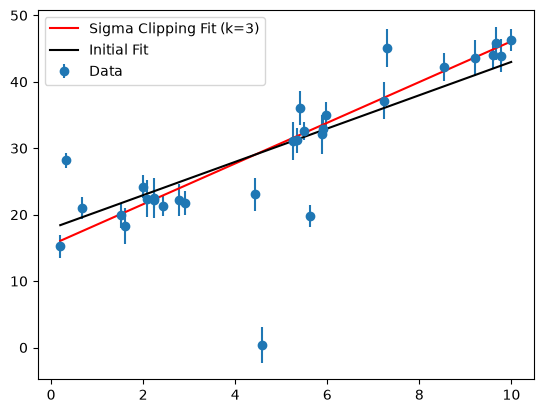

In [49]:
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x[mask], sigma_fit, color = "red", label = 'Sigma Clipping Fit (k=3)')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.legend();

### Mixture Model

In [51]:
### BELOW FROM WEEK 2 -> LECTURE 3: "The mixture-model likelihood (Hogg, Bovy & Lang 2010)"
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

In [52]:
theta0 = [m_best, b_best, 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='BFGS')

m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
mix_fit = m_mix*x + b_mix

cov_mix = result.hess_inv          
sigma_m_mix, sigma_b_mix = np.sqrt(np.diag(cov_mix))[:2]

chi_sq_mix = np.sum( (( y - mix_fit) / sigma_y)**2 )
reduced_chi_sq_mix = chi_sq_mix / (len(y) - 2) # the two fitted parameters are B0 and B1 (m and b)
R2_mix = r2_score(y, mix_fit)
RMSE_mix = root_mean_squared_error(y, mix_fit)

print(f"The Reduced Chi-Squared for the initial linear model is: {reduced_chi_sq_mix:.4f} (with masked x and y)")
print(f"R2 = {R2_mix:.4f}, RMSE = {RMSE_mix:.4f}")
print(f"outlier fraction Pb = {Pb_mix:.4f}")
print(f"m: {m_mix:.4f} +- {sigma_m_mix:.4f}")
print(f"b: {b_mix:.4f} +- {sigma_b_mix:.4f}")

The Reduced Chi-Squared for the initial linear model is: 10.9659 (with masked x and y)
R2 = 0.6361, RMSE = 6.5816
outlier fraction Pb = 0.1400
m: 3.0741 +- 0.1625
b: 15.4202 +- 0.9507


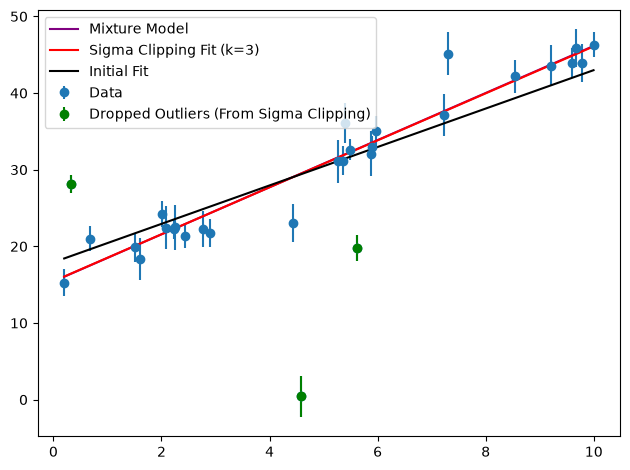

In [53]:
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x, mix_fit, color = "purple", label = "Mixture Model")
plt.plot(x[mask], sigma_fit, color = "red", label = 'Sigma Clipping Fit (k=3)')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.errorbar(x[~mask], y[~mask], sigma_y[~mask], fmt = 'o', color = "green", label = "Dropped Outliers (From Sigma Clipping)")
plt.legend()
plt.tight_layout();

In [54]:
ai_solution = [2.8879, 0.6325, 16.2875,3.6430, 6.557] #m, sigma_m, b, sigma_b, chi_sq for ai solution
slopes = [m, m_best, m_mix, ai_solution[0]]
intercepts = [b,b_best, b_mix, ai_solution[2]]
sigmas_m = [sigma_m, sigma_m_best, sigma_m_mix, ai_solution[1]]
sigmas_b = [sigma_b, sigma_b_best, sigma_b_mix, ai_solution[3]]
red_chi_sq = [reduced_chi_sq, reduced_chi_sq_sig, reduced_chi_sq_mix, ai_solution[4]]
fit_names = ["Initial Fit", "Sigma Clipped Fit", "Mixure Model", "AI Solution"]
table = {"Model Name": fit_names,
         "slopes" : slopes,
         "intercepts": intercepts,
         "sigma_m": sigmas_m,
         "sigma_b": sigmas_b,
         "red_chi_sq": red_chi_sq}
lms = pd.DataFrame(table)
lms

,Model Name,slopes,intercepts,sigma_m,sigma_b,red_chi_sq
0,Initial Fit,2.507509,17.919933,0.114041,0.600940,10.082995
1,Sigma Clipped Fit,3.064647,15.446786,0.125793,0.697952,1.119947
2,Mixure Model,3.074062,15.420211,0.162470,0.950730,10.965925
3,AI Solution,2.887900,16.287500,0.632500,3.643000,6.557000


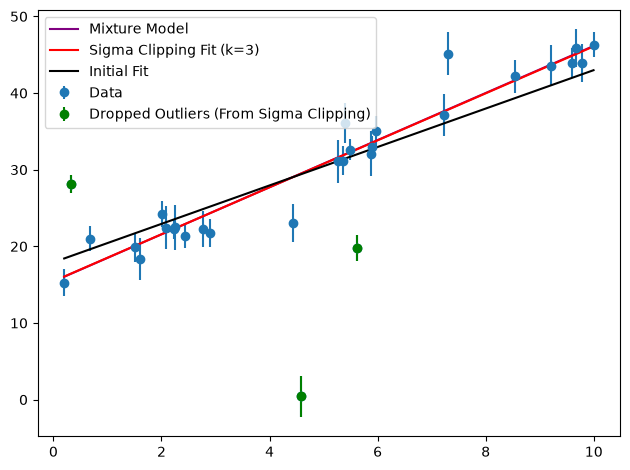

In [55]:
plt.errorbar(x, y, sigma_y, fmt='o', label='Data')
plt.plot(x, mix_fit, color = "purple", label = "Mixture Model")
plt.plot(x[mask], sigma_fit, color = "red", label = 'Sigma Clipping Fit (k=3)')
plt.plot(x, initial_fit, color = "black", label = 'Initial Fit')
plt.errorbar(x[~mask], y[~mask], sigma_y[~mask], fmt = 'o', color = "green", label = "Dropped Outliers (From Sigma Clipping)")
plt.legend()
plt.tight_layout();

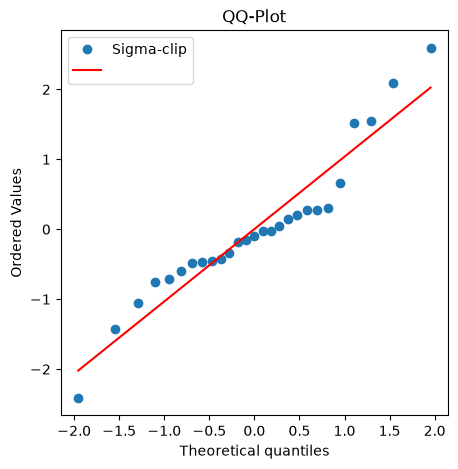

In [190]:
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot((y[mask] - (m_best*x[mask] + b_best)) / sigma_y[mask], dist="norm", plot=ax)

ax.get_lines()[0].set_color("C0")
ax.get_lines()[1].set_color("red")
ax.legend(["Sigma-clip", "", "Mixture model", ""])
ax.set_title("QQ-Plot")
plt.show()


**FINAL ANSWER:** $m = $ 3.074062  $\pm$ 0.162470 , $b = $ 15.420211 $\pm$ 0.950730 , outlier fraction $\approx$ 0.1400

**Justification and uncertainty method (a short paragraph):**

The m, sigma_m, b, and sigma_b are the values from the Mixture Model. The line drawn using this models slope and intercept visually appears to accurately reflect the relationship of x and y in the dataset. This mixture model was created and evaluated without dropping any of the other points (like the Sigma Clipped Model) which improves the interpretability and reliability of evaluation metrics like $R^2$ and Chi Squared, and it shared a very similar slope and intercept with the sigma clipped model which had impressive evaluation metrics on the data with removed outliers (meaning the fit was strong on the data without outliers). Not dropping outliers while having a nearly identical fit to the model that dropped the outliers is garunteed to be a better choice as it does not eliminate the signal the outliers may carry completely and may make it easier for downstream comparisons and analyses of other models or features in the full dataset.

## Part 3: The referee report (30%)

**REFEREE REPORT:**

*Flaw 1:* 

- On the AI solution initial fit method, it uses the argument for `np.polyfit` cov = True; according to the documentation, "By default, the covariance are scaled by chi2/dof, where dof = M - (deg + 1), i.e., the weights are presumed to be unreliable except in a relative sense and everything is scaled such that the reduced chi2 is unity. This scaling is omitted if cov='unscaled', as is relevant for the case that the weights are w = 1/sigma, with sigma known to be a reliable estimate of the uncertainty." This inflation of reduced chi squared makes the fit look better than it is, and inflates the error bars for the estimators. To see this inflation, I tested how much the uncertainty in m and b changed if the argument was set to True or unscaled; the change in sigma_m was **0.3473**, and the change in sigma_b was **1.988** which are both significantly different.

*Flaw 2:*

- When using `np.polyfit` in the AI solution, the function never took any weight argument, `w`, so the linear model did not account for the fact that some measurements had a much larger sigma_y and others had a much smaller one, leading to all points to be treated the same to have the same uncertainty (which may inflate sigma_m and sigma_b. The weights should have been 1 over sigma_y for each point. The actual change in m was **0.4123**, the change in b was **-2.7569**, the change in sigma_m was **0.0460**, and the change in sigma_b was **0.428**.

*Flaw 3:*

- When calculating the sigma clipping threshold, the AI solution takes the standard deviation of all the residuals (a single number) instead of taking the standard deviation associated with each residual in the code `threshold = 3 * np.std(residuals)`. This has the effect of including the outliers in the actual standard deviation calculation, as well as ignoring the true sigma_y of each point as shown in the formula:
 $$\left|\frac{y_i - \mathrm{model}(x_i)}{\sigma_i}\right| < k$$

- The outlier fraction goes from **0.10** with a proper implementation (3 points dropped), to **0.033** in the AI solution (1 point dropped).

In [113]:
# Part 3: demonstrations here
#flaw 1

coeffs, cov = np.polyfit(x, y, 1, cov=True) 
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
print(f"\nSlope:     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"Intercept: b = {b_fit:.4f} +/- {b_err:.4f}\n")

print("---------------------------------------------------\n")
print("Flaw 1")
coeffs, cov = np.polyfit(x, y, 1, cov="unscaled") # from ai sol
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
print(f"Slope (Unscaled):     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"Intercept (Unscaled): b = {b_fit:.4f} +/- {b_err:.4f}\n")

#flaw 2
print("---------------------------------------------------\n")
print("Flaw 2")
coeffs2, cov2 = np.polyfit(x, y, 1, w = 1/sigma_y, cov=True) # test
m_fit, b_fit = coeffs2
m_err, b_err = np.sqrt(np.diag(cov2))
print(f"Slope (with sigma_y weights):     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"Intercept (with sigma_y weights): b = {b_fit:.4f} +/- {b_err:.4f}\n")

#flaw 3
print("---------------------------------------------------\n")
print("Flaw 3")
print(f"My solution outlier fraction: {3/30}, AI solution outlier faction: {1/30:.3f}")


Slope:     m = 2.9198 +/- 0.4081
Intercept: b = 15.1630 +/- 2.3358

---------------------------------------------------

Flaw 1
Slope (Unscaled):     m = 2.9198 +/- 0.0608
Intercept (Unscaled): b = 15.1630 +/- 0.3478

---------------------------------------------------

Flaw 2
Slope (with sigma_y weights):     m = 2.5075 +/- 0.3621
Intercept (with sigma_y weights): b = 17.9199 +/- 1.9082

---------------------------------------------------

Flaw 3
My solution outlier fraction: 0.1, AI solution outlier faction: 0.033


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I used Claude on this assignment to first better understand the pitfalls of rescaling Chi Squared as shown in the in-class example and AI solution (to also avoid it in my implementation). Then I needed summarized assistance in evaluating the different ways I could fit a linear model to data; in the past I have used scipy, statsmodels.api, and scikit learn and the AI output helped me understand what exactly each library was better for and worse for specifically in this lab. It also helped refresh some of the syntax and describe some of the variables output from the related functions. I then wanted to understand Sigma Clipping and the Mixture Model (with review for the log likelyhood function). I then had a bug in my Sigma Clipping implementation inspired from the lecture notes but that I adapted for using scipy instead (applied the mask on arrays I should not have at first). To summarize, I used AI to really understand the background knowledge on the 2 different ways to handle the outliers in the data, to create the QQ diagnostic plot, and to understand the true effect of ignoring the sigma_y column in the AI solution notebook. It also assisted me in finding tiny bugs that would trip my code up.

**VERIFICATION PLAN:**

- Marked all parameters in a table for easy visual comparison (Failure would show the sigma clipped model and the mixture model m and b to be significantly different).
- Plotted all fits on the same figure to see the best fit (failure would show that the lines would not visually look like a good fit for the scattered data points).
- Plot the Sigma Clipped Model QQ plots to view how outliers affect the diagnostic plot (failure would show that the numbers around the center of the plot hug the line y=x well, while we already expect more variation in that fit of the line y=x due to the strength of outliers)
